# Random Forest Sentiment Classification
Random Forest - classify IMDB reviews as negative (0) or positive (1)

## 1. Import libraries and set reproducibility

In [12]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and validate the cleaned dataset

The EDA notebook already produced `final_review` (cleaned text) and `label` (0 = negative, 1 = positive), so no raw-text cleaning is repeated here.

In [ ]:
# import cleaned dataset
candidate_paths = [
    Path("../txsa_p2/txsa_p2/imdb_cleaned.csv"),
    Path("TSXA/txsa_p2/txsa_p2/imdb_cleaned.csv"),
    Path("txsa_p2/txsa_p2/imdb_cleaned.csv"),
]
data_path = next((path.resolve() for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find imdb_cleaned.csv. Check the candidate paths in this cell."
    )

# Load only the two columns required by the model to reduce memory usage.
df = pd.read_csv(data_path, usecols=["final_review", "label"])

print(f"Dataset: {data_path}")
print(f"Loaded shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(3))

Dataset: C:\Users\ggshe\OneDrive - Asia Pacific University of Technology And Innovation (APU)\APU - Year 3\TXSA\source\TSXA\txsa_p2\txsa_p2\imdb_cleaned.csv
Loaded shape: 50,000 rows x 2 columns


,label,final_review
0,1,one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality...
1,1,wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting ...
2,1,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lighthearted comedy plo...


In [14]:
# Rename the fields to short, model-oriented names and validate their contents.
model_df = df.rename(columns={"final_review": "text"}).copy()
model_df = model_df.dropna(subset=["text", "label"])
model_df["text"] = model_df["text"].astype(str).str.strip()
model_df = model_df.loc[model_df["text"].ne("")].copy()
model_df["label"] = model_df["label"].astype(int)

if not set(model_df["label"].unique()).issubset({0, 1}):
    raise ValueError("The label column must contain only 0 (negative) and 1 (positive).")

# Identical reviews must not occur in both train and test sets because that would
# leak the answer and make the test performance appear better than it really is.
conflicting_texts = model_df.groupby("text")["label"].nunique().gt(1).sum()
if conflicting_texts:
    raise ValueError(f"Found {conflicting_texts} duplicate texts with conflicting labels.")

rows_before = len(model_df)
model_df = model_df.drop_duplicates(subset="text").reset_index(drop=True)
duplicates_removed = rows_before - len(model_df)

class_summary = (
    model_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "negative (0)", 1: "positive (1)"})
    .rename("reviews")
    .to_frame()
)

print(f"Missing/empty rows removed: {len(df) - rows_before:,}")
print(f"Exact duplicate reviews removed: {duplicates_removed:,}")
print(f"Rows available for modelling: {len(model_df):,}")
display(class_summary)

Missing/empty rows removed: 0
Exact duplicate reviews removed: 423
Rows available for modelling: 49,577


,reviews
label,
negative (0),24695
positive (1),24882


## 3. Create a stratified train/test split

The test set is held out before TF-IDF fitting. Stratification preserves the positive/negative balance in both subsets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df["text"],
    model_df["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=model_df["label"],
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "negative": [(y_train == 0).sum(), (y_test == 0).sum()],
        "positive": [(y_train == 1).sum(), (y_test == 1).sum()],
    },
    index=["Training set", "Test set"],
)
display(split_summary)

,rows,negative,positive
Training set,39661,19756,19905
Test set,9916,4939,4977


## 4. Build and train the TF-IDF + Random Forest pipeline

- **TF-IDF** gives more weight to informative terms and less weight to terms common across many reviews.
- Unigrams and bigrams capture both individual words and short phrases such as `great movie`.
- The pipeline fits TF-IDF using training data only, preventing test-data leakage.
- `class_weight="balanced_subsample"` keeps the classifier robust if the class distribution changes.

In [16]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=30_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
        ),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

fit_start = perf_counter()
random_forest_pipeline.fit(X_train, y_train)
fit_seconds = perf_counter() - fit_start

feature_count = len(
    random_forest_pipeline.named_steps["tfidf"].get_feature_names_out()
)
print(f"Training completed in {fit_seconds:,.2f} seconds.")
print(f"TF-IDF features used: {feature_count:,}")

Training completed in 44.63 seconds.
TF-IDF features used: 30,000


## 5. Evaluate performance on unseen test reviews

For the positive class: precision measures how many predicted-positive reviews were correct, recall measures how many actual-positive reviews were found, and F1-score balances precision and recall. ROC-AUC evaluates probability ranking across classification thresholds.

In [17]:
predict_start = perf_counter()
y_pred = random_forest_pipeline.predict(X_test)
y_probability = random_forest_pipeline.predict_proba(X_test)[:, 1]
predict_seconds = perf_counter() - predict_start

metric_values = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
}
metrics_df = pd.DataFrame.from_dict(
    metric_values, orient="index", columns=["Test score"]
)

print(f"Prediction completed in {predict_seconds:,.2f} seconds.")
display(metrics_df.round(4))

Prediction completed in 3.20 seconds.


,Test score
Accuracy,0.8593
Precision,0.8517
Recall,0.8714
F1-score,0.8615
ROC-AUC,0.9361


In [18]:
# The class-wise report shows whether the model performs similarly for both sentiments.
report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["negative", "positive"],
    output_dict=True,
    zero_division=0,
)
# Accuracy is already reported in the summary table, so keep this table focused
# on class-level and averaged precision, recall, F1-score, and support.
report_df = pd.DataFrame(report).T.loc[
    ["negative", "positive", "macro avg", "weighted avg"]
]
report_df[["precision", "recall", "f1-score"]] = report_df[
    ["precision", "recall", "f1-score"]
].round(4)
report_df["support"] = report_df["support"].round().astype(int)
display(report_df)

,precision,recall,f1-score,support
negative,0.8673,0.8471,0.8571,4939
positive,0.8517,0.8714,0.8615,4977
macro avg,0.8595,0.8593,0.8593,9916
weighted avg,0.8595,0.8593,0.8593,9916


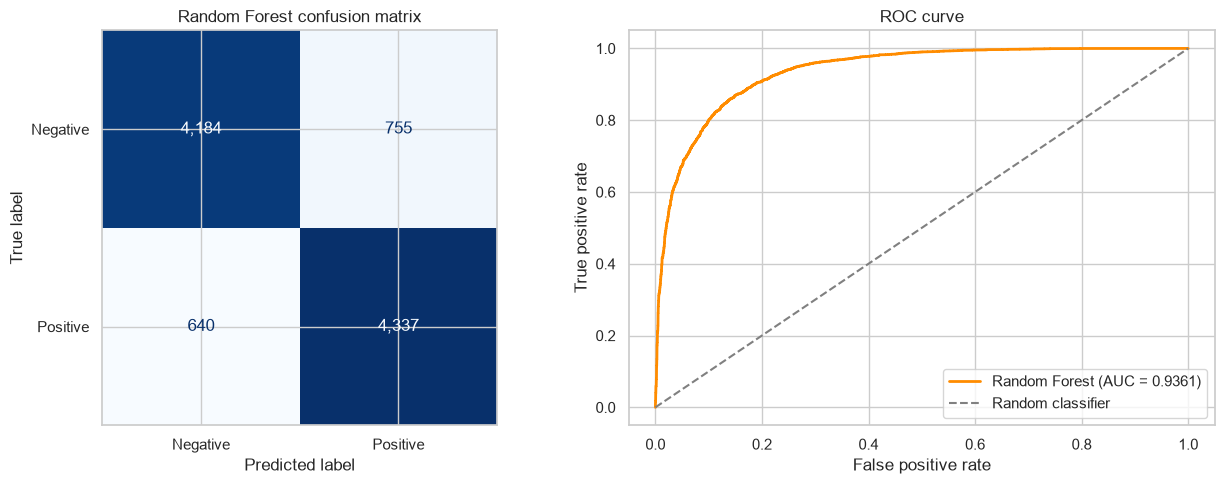

In [19]:
# Visualise correct and incorrect predictions, plus threshold-independent ROC performance.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"],
).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format=",d")
axes[0].set_title("Random Forest confusion matrix")

axes[1].plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"Random Forest (AUC = {metric_values['ROC-AUC']:.4f})",
)
axes[1].plot([0, 1], [0, 1], "--", color="grey", label="Random classifier")
axes[1].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="ROC curve",
)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. Inspect influential TF-IDF features

Random Forest feature importance indicates which words or phrases contributed most to the tree decisions. Importance magnitude does not by itself indicate whether a term predicts positive or negative sentiment.

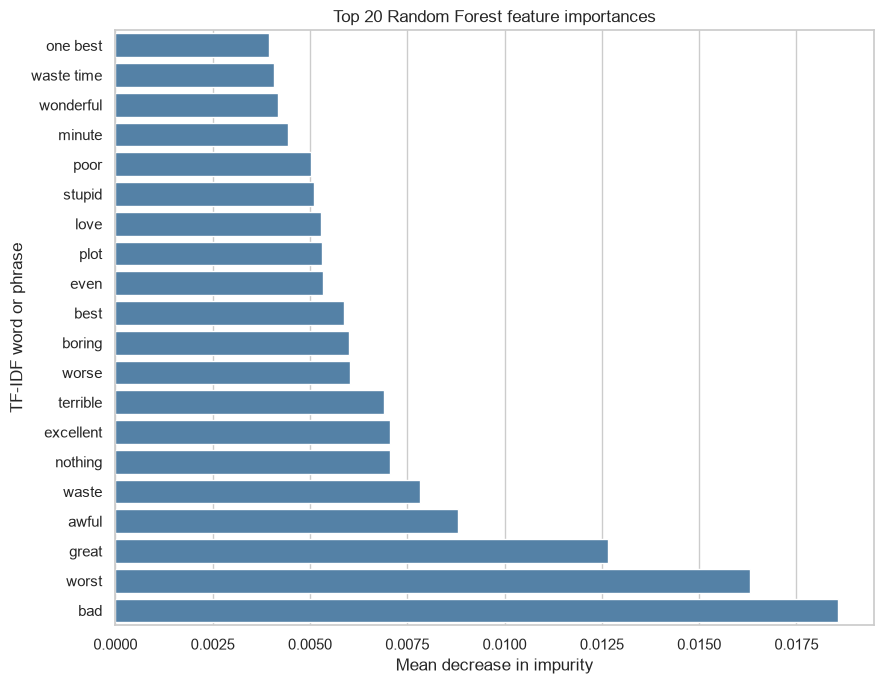

In [20]:
feature_names = random_forest_pipeline.named_steps["tfidf"].get_feature_names_out()
feature_importances = random_forest_pipeline.named_steps[
    "random_forest"
].feature_importances_

top_features = (
    pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    .nlargest(20, "importance")
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))
sns.barplot(data=top_features, x="importance", y="feature", color="steelblue")
plt.title("Top 20 Random Forest feature importances")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("TF-IDF word or phrase")
plt.tight_layout()
plt.show()

## 7. Review a small sample of classification errors

Error examples help reveal difficult language such as mixed opinions, sarcasm, or sentiment words used in unusual contexts.

In [21]:
error_df = pd.DataFrame(
    {
        "review": X_test.reset_index(drop=True),
        "actual": y_test.reset_index(drop=True),
        "predicted": y_pred,
        "positive_probability": y_probability,
    }
)
error_df = error_df.loc[error_df["actual"] != error_df["predicted"]].copy()
error_df["actual"] = error_df["actual"].map({0: "negative", 1: "positive"})
error_df["predicted"] = error_df["predicted"].map({0: "negative", 1: "positive"})

# A fixed random_state keeps this displayed sample reproducible.
error_sample = error_df.sample(n=min(6, len(error_df)), random_state=RANDOM_STATE)
error_sample["positive_probability"] = error_sample[
    "positive_probability"
].round(4)
display(error_sample)

,review,actual,predicted,positive_probability
8660,feel extremely sad people reviewing film apparent standard high never able enjoy film enjoyment sake perhaps enjoyme...,positive,negative,0.4621
3077,worse way spend evening watching movie although tad predictable drew barrymore good job outcast nerd film excellent ...,positive,negative,0.4376
9860,one thing sureyou watch film bad day story based around sad event follows character live sin cant handle story drip ...,positive,negative,0.4531
5077,first forty minute luna real pleasure watch character situation interesting photography location beautiful look jill...,negative,positive,0.5189
4329,film enjoyable wrong reason coordination action sequence laughable make film funny slap stick moment robert ginty fr...,positive,negative,0.4439
670,even though animated film really bored everyone least grown grew area wild horse native american felt combination pc...,negative,positive,0.5688


## 8. Concise result summary

In [22]:
tn, fp, fn, tp = cm.ravel()

print("RANDOM FOREST TEST-SET SUMMARY")
print("-" * 38)
print(f"Test reviews : {len(y_test):,}")
print(f"Accuracy     : {metric_values['Accuracy']:.4f}")
print(f"Precision    : {metric_values['Precision']:.4f}")
print(f"Recall       : {metric_values['Recall']:.4f}")
print(f"F1-score     : {metric_values['F1-score']:.4f}")
print(f"ROC-AUC      : {metric_values['ROC-AUC']:.4f}")
print(f"Correct      : {tn + tp:,}")
print(f"Incorrect    : {fp + fn:,}")
print("\nInterpretation:")
print(
    "The held-out results estimate how well this TF-IDF Random Forest model "
    "classifies unseen cleaned IMDB reviews."
)

RANDOM FOREST TEST-SET SUMMARY
--------------------------------------
Test reviews : 9,916
Accuracy     : 0.8593
Precision    : 0.8517
Recall       : 0.8714
F1-score     : 0.8615
ROC-AUC      : 0.9361
Correct      : 8,521
Incorrect    : 1,395

Interpretation:
The held-out results estimate how well this TF-IDF Random Forest model classifies unseen cleaned IMDB reviews.
